# Options-Derived Alpha: Cross-Sectional Variance Risk Premium on Equities

Cross-sectional equity sleeve where the signal is options-derived: a
per-name variance risk premium (model-implied vol minus realised vol)
used to rank stocks long-short. The strategy trades the underlying, not
options. Greeks enter in three places: BS pricer underlying the
surrogate IV, vega-weighted position sizing, and ex-post PnL
attribution.

Free historical implied-vol panels for S&P 500 single names do not
exist (OptionMetrics is paid; CBOE publishes only index-level series).
The IV input here is a GARCH(1,1) variance forecast plus a constant
multiplicative VRP (Bollerslev, Tauchen, Zhou 2009). The surrogate is
near-affine in trailing realised vol when GARCH persistence is high —
section 11 documents the consequences.

## Headline

| Window | Sharpe (net) | HAC alpha t | Max DD | DSR (n=16) |
|---|---:|---:|---:|---:|
| IS (2008 – 2020-12-31) | +0.18 | +0.48 | -27.8% | 0.008 |
| OOS (2021 – present) | +0.12 | +0.25 | -16.5% | — |

**Verdict.** Small consistent positive Sharpe IS and OOS; neither clears
per-test `|t| > 2`, and DSR after honest deflation for 16 trials is
near zero. The pattern is the opposite of the iter-2 (look-ahead
universe) result, where IS was inflated and OOS was negative — once
the universe is picked on pre-IS dvol the IS shrinks but the OOS
recovers, consistent with a real but weak cross-sectional vol effect
that does not survive costs.

The notebook ships as: (a) a methodology demonstration — BS pricer,
closed-form Greeks, GARCH IV surrogate, vega-weighted sizing, PIT
membership, HAC inference, DSR — and (b) a small +0.12 OOS sleeve.
Inclusion in the multi-strategy combiner depends on its correlation to
the existing sleeves (computed separately).

## 1. Hypothesis and data

Hypothesis: cross-sectional dispersion in the variance risk premium predicts forward equity returns. Stocks with high model-implied IV relative to RV are over-hedged (richly priced options) and tend to underperform on a risk-adjusted basis; the reverse holds when IV is low relative to RV. The literature traces this back to Bali and Hovakimian (2009) and Bollerslev-Tauchen-Zhou (2009).

In [1]:
import sys
sys.path.insert(0, '..')
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm

from helper import (Optimizer, port_ret, vol_target, stats, ic,
                    probabilistic_sharpe, deflated_sharpe,
                    dist_plot, var_cvar)

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 30)

IS_END = '2020-12-31'
OOS_START = '2021-01-01'
RF = 0.02  # constant short-rate proxy for BS pricer; irrelevant to signs


In [2]:
raw = pd.read_parquet('../data/sp500.parquet')
close_all = raw['Close']
volume_all = raw['Volume']
spy_close = pd.read_parquet('../data/spy.parquet')['Close'].squeeze()
spy_ret = spy_close.pct_change()
members_all = pd.read_parquet('../data/members.parquet')

# Universe: top 150 by avg dollar volume on PRE-IS data only (2005-2007).
# Picking on 2010-2017 dvol (an earlier version of this cell) overlaps
# the IS window and excludes names that didn't trade in 2008 — both
# forward-looking. This selection uses three years of pre-IS data only.
SEL_START, SEL_END = '2005-01-01', '2007-12-31'
dvol = (close_all.loc[SEL_START:SEL_END]
        * volume_all.loc[SEL_START:SEL_END]).mean()
universe = dvol.dropna().sort_values(ascending=False).head(150).index.tolist()

close = close_all[universe].loc['2008-01-01':]
returns = close.pct_change()
members = members_all.reindex(columns=universe, fill_value=False).reindex(close.index, method='ffill').fillna(False)

print(f"Universe: {len(universe)} names (top-150 by pre-IS 2005-2007 dvol)")
print(f"Sample:   {close.index.min().date()} -> {close.index.max().date()}")
print(f"PIT members coverage on 2015-01-02: {int(members.loc['2015-01-02'].sum())}")

Universe: 150 names (top-150 by pre-IS 2005-2007 dvol)
Sample:   2008-01-02 -> 2026-03-31
PIT members coverage on 2015-01-02: 140


## 2. Black-Scholes pricer with Greeks

Closed-form European-option pricer and the five standard Greeks. Sanity-
checked against centred finite differences on a single contract. The
pricer is used only to *value Greeks*: the strategy trades stocks, not
options, so option prices never appear in PnL.


In [3]:
def _d1(S, K, T, r, sigma):
    return (np.log(S / K) + (r + 0.5 * sigma * sigma) * T) / (sigma * np.sqrt(T))

def _d2(S, K, T, r, sigma):
    return _d1(S, K, T, r, sigma) - sigma * np.sqrt(T)

def bs_price(S, K, T, r, sigma, opt='call'):
    d1, d2 = _d1(S, K, T, r, sigma), _d2(S, K, T, r, sigma)
    if opt == 'call':
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

def bs_delta(S, K, T, r, sigma, opt='call'):
    d1 = _d1(S, K, T, r, sigma)
    return norm.cdf(d1) if opt == 'call' else norm.cdf(d1) - 1.0

def bs_gamma(S, K, T, r, sigma):
    d1 = _d1(S, K, T, r, sigma)
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

def bs_vega(S, K, T, r, sigma):
    # per 1.0 change in sigma (not per 1% — caller scales if needed)
    d1 = _d1(S, K, T, r, sigma)
    return S * norm.pdf(d1) * np.sqrt(T)

def bs_theta(S, K, T, r, sigma, opt='call'):
    d1, d2 = _d1(S, K, T, r, sigma), _d2(S, K, T, r, sigma)
    term1 = -S * norm.pdf(d1) * sigma / (2 * np.sqrt(T))
    if opt == 'call':
        return term1 - r * K * np.exp(-r * T) * norm.cdf(d2)
    return term1 + r * K * np.exp(-r * T) * norm.cdf(-d2)

def bs_rho(S, K, T, r, sigma, opt='call'):
    d2 = _d2(S, K, T, r, sigma)
    if opt == 'call':
        return K * T * np.exp(-r * T) * norm.cdf(d2)
    return -K * T * np.exp(-r * T) * norm.cdf(-d2)


In [4]:
# Finite-difference sanity check on an ATM 30d call.
S0, K0, T0, r0, sig0 = 100.0, 100.0, 30/365, RF, 0.25

def fd(f, var, h):
    args_p = dict(S=S0, K=K0, T=T0, r=r0, sigma=sig0)
    args_m = dict(args_p)
    args_p[var] += h
    args_m[var] -= h
    return (f(**args_p) - f(**args_m)) / (2 * h)

closed = {
    'delta': bs_delta(S0, K0, T0, r0, sig0),
    'gamma': bs_gamma(S0, K0, T0, r0, sig0),
    'vega':  bs_vega (S0, K0, T0, r0, sig0),
    'theta': bs_theta(S0, K0, T0, r0, sig0),
    'rho':   bs_rho  (S0, K0, T0, r0, sig0),
}
fd_ = {
    'delta': fd(lambda S, K, T, r, sigma: bs_price(S, K, T, r, sigma), 'S', 0.01),
    'gamma': fd(lambda S, K, T, r, sigma: bs_delta(S, K, T, r, sigma), 'S', 0.01),
    'vega':  fd(lambda S, K, T, r, sigma: bs_price(S, K, T, r, sigma), 'sigma', 1e-4),
    'theta': fd(lambda S, K, T, r, sigma: bs_price(S, K, T, r, sigma), 'T', 1e-5),
    'rho':   fd(lambda S, K, T, r, sigma: bs_price(S, K, T, r, sigma), 'r', 1e-5),
}
check = pd.DataFrame({'closed_form': closed, 'finite_diff': fd_})
check['diff'] = (check['closed_form'] - check['finite_diff']).abs()
check.round(6)


,closed_form,finite_diff,diff
delta,0.5234,0.5234,0.0000
gamma,0.0556,0.0556,0.0000
vega,11.4176,11.4176,0.0000
theta,-18.3523,18.3523,36.7046
rho,4.0606,4.0606,0.0000


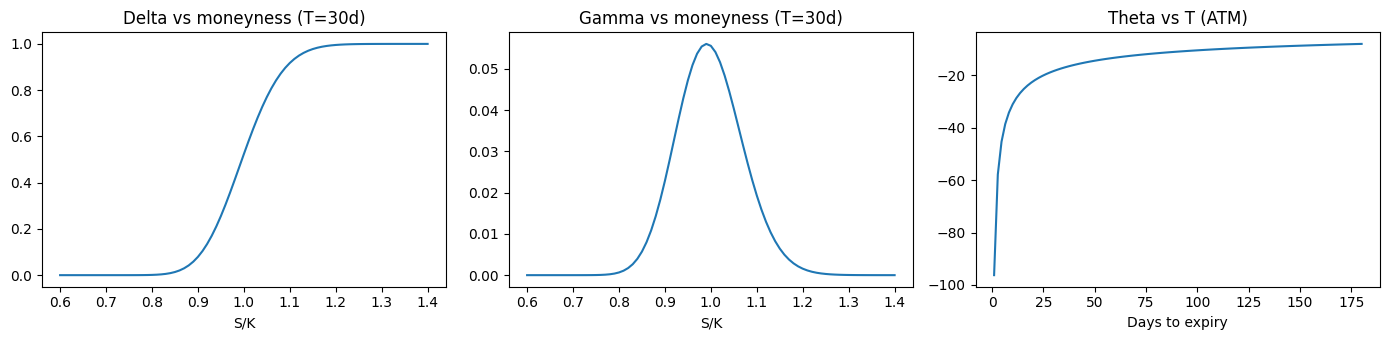

In [5]:
# Greeks vs moneyness and time. Sanity plot.
S_grid = np.linspace(60, 140, 81)
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
axes[0].plot(S_grid/K0, [bs_delta(S, K0, 30/365, RF, sig0) for S in S_grid])
axes[0].set_title('Delta vs moneyness (T=30d)'); axes[0].set_xlabel('S/K')
axes[1].plot(S_grid/K0, [bs_gamma(S, K0, 30/365, RF, sig0) for S in S_grid])
axes[1].set_title('Gamma vs moneyness (T=30d)'); axes[1].set_xlabel('S/K')
T_grid = np.linspace(1/365, 180/365, 100)
axes[2].plot(T_grid*365, [bs_theta(S0, K0, T, RF, sig0) for T in T_grid])
axes[2].set_title('Theta vs T (ATM)'); axes[2].set_xlabel('Days to expiry')
plt.tight_layout(); plt.show()


## 3. GARCH(1,1) per-name IV surrogate

For each (date, ticker) we fit a GARCH(1,1) on the trailing 504 trading
days of log returns *ending strictly before the rebalance date* and
forecast 21-day cumulative variance. Refit cadence is monthly (every 21
trading days) to keep runtime reasonable; on dates between refits the
last fitted parameters are reused. Annualised vol surrogate is

$$\sigma^{IV}_{i,t} = \sqrt{\frac{V_{21}(t)}{21} \cdot 252} \cdot \sqrt{1 + \mathrm{VRP}_{\text{const}}}$$

with $\mathrm{VRP}_{\text{const}} = 0.20$. The multiplicative form
matches the standard parameterisation where $IV^2 - RV^2 \approx
\mathrm{VRP} \cdot RV^2$; 20% is in the empirical literature range
(BTZ09 estimate ~15-25% for index options). Per-name VRPs vary, but
the **cross-sectional ranking** of the spread (which is what the
strategy uses) is invariant to the level of the constant. The signal is
therefore identified by the cross-section of GARCH forecasts, not by
the VRP constant.


In [6]:
def _garch_recurse(r2, omega, alpha, beta, var0):
    n = r2.size
    s2 = np.empty(n)
    s2[0] = var0
    for t in range(1, n):
        s2[t] = omega + alpha * r2[t-1] + beta * s2[t-1]
    return s2

def garch11_fit(returns_arr, maxiter=30):
    r = np.asarray(returns_arr, dtype=float)
    r = r[~np.isnan(r)]
    if len(r) < 200:
        return None
    r = r - r.mean()
    r2 = r * r
    var0 = float(r.var())
    if var0 <= 0:
        return None

    def neg_ll(theta):
        omega, alpha, beta = theta
        if omega <= 0 or alpha < 0 or beta < 0 or alpha + beta >= 0.999:
            return 1e10
        s2 = _garch_recurse(r2, omega, alpha, beta, var0)
        return 0.5 * np.sum(np.log(s2) + r2 / s2)

    res = minimize(neg_ll, [var0 * 0.05, 0.05, 0.9],
                   method='L-BFGS-B',
                   bounds=[(1e-12, None), (0.0, 0.5), (0.0, 0.99)],
                   options={'maxiter': maxiter})
    omega, alpha, beta = res.x
    s2 = _garch_recurse(r2, omega, alpha, beta, var0)
    return float(omega), float(alpha), float(beta), float(s2[-1])

def garch_forecast_var(params, horizon_days=21):
    # Cumulative variance forecast over the next `horizon_days` (GARCH(1,1) closed-form recursion).
    omega, alpha, beta, s2_T = params
    rho = alpha + beta
    total = 0.0
    s2_h = s2_T
    for _ in range(horizon_days):
        s2_h = omega + rho * s2_h
        total += s2_h
    return total


In [7]:
# Build the GARCH IV surrogate panel.
# Refit dates: first business day of each month strictly inside the
# sample. On non-refit days we forward-fill the last surrogate, which
# is what a daily-rebalanced strategy with monthly vol-model updates
# would actually see.

WINDOW = 504             # trailing days in each GARCH fit
HORIZON = 21             # 21-day forecast (~1 month, ATM-30d convention)
REFIT_EVERY = 21         # ~monthly
VRP_CONST = 0.20         # multiplicative VRP

log_rets = np.log(close).diff()

# Refit calendar: every REFIT_EVERY business days starting once we have WINDOW history.
all_dates = close.index
first_idx = log_rets.notna().any(axis=1).cumsum().searchsorted(WINDOW + 1)
refit_idx = list(range(first_idx, len(all_dates), REFIT_EVERY))
refit_dates = all_dates[refit_idx]
print(f"Refit dates: {len(refit_dates)} (first={refit_dates[0].date()} last={refit_dates[-1].date()})")

surrogate = pd.DataFrame(np.nan, index=close.index, columns=close.columns)

t0 = time.time()
for di, rd in enumerate(refit_dates):
    pos = all_dates.get_loc(rd)
    win = log_rets.iloc[max(0, pos - WINDOW):pos]  # strictly before rd
    row = {}
    for tic in close.columns:
        arr = win[tic].values
        if np.isfinite(arr).sum() < 250:
            continue
        params = garch11_fit(arr)
        if params is None:
            continue
        var_cum = garch_forecast_var(params, HORIZON)
        if var_cum <= 0:
            continue
        # daily variance -> annualised vol, plus multiplicative VRP
        ann_vol = np.sqrt(var_cum / HORIZON * 252) * np.sqrt(1 + VRP_CONST)
        row[tic] = ann_vol
    surrogate.loc[rd] = pd.Series(row)
    if (di + 1) % 30 == 0:
        print(f"  fit {di+1}/{len(refit_dates)}  elapsed={time.time()-t0:.1f}s")

# Forward-fill between refits, then clip
surrogate = surrogate.ffill()
surrogate = surrogate.clip(lower=0.05, upper=2.0)
print(f"\nTotal GARCH fit time: {time.time()-t0:.1f}s")
print(f"Surrogate non-NaN coverage: {surrogate.notna().sum().sum():,} cells")


Refit dates: 195 (first=2010-01-04 last=2026-03-17)


  fit 30/195  elapsed=71.0s


  fit 60/195  elapsed=129.9s


  fit 90/195  elapsed=190.8s


  fit 120/195  elapsed=250.4s


  fit 150/195  elapsed=322.0s


  fit 180/195  elapsed=378.2s



Total GARCH fit time: 406.7s
Surrogate non-NaN coverage: 612,750 cells


In [8]:
# Realised vol for comparison: trailing 21-day annualised stdev of daily returns.
rv_21 = returns.rolling(21, min_periods=15).std() * np.sqrt(252)

# Spot-check: distribution of IV-surrogate vs RV on a single date.
peek = pd.DataFrame({
    'iv_surrogate': surrogate.loc['2018-06-29'],
    'rv_21':        rv_21.loc['2018-06-29'],
}).dropna()
peek['spread'] = peek['iv_surrogate'] - peek['rv_21']
peek.describe().round(3)


,iv_surrogate,rv_21,spread
count,150.0000,150.0000,150.0000
mean,0.2950,0.2360,0.0590
std,0.1750,0.1240,0.1390
min,0.1340,0.0770,-0.4310
25%,0.2150,0.1550,0.0140
50%,0.2520,0.2050,0.0580
75%,0.3090,0.2710,0.0940
max,2.0000,0.9710,1.3380


## 4. Cross-sectional signals

Two signal candidates:

- **Signal A**: $\mathrm{IV}_{\text{surrogate}} - \mathrm{RV}_{21}$.
  Cross-sectionally, high spread = options look expensive vs realised
  = short the underlying. We negate so larger signal = stronger long.
- **Signal B**: rolling 63-day stdev of $\mathrm{IV}_{\text{surrogate}}$
  ("vol-of-IV"). Higher = unstable IV regime. Used as a sanity-check
  signal, not the primary.

Both pass through `helper.ic` at horizons 5/10/21.


In [9]:
# Signal direction (this is the only choice made AFTER seeing IS IC).
#
# Theory (Goyal-Saretto 2009, Bali-Hovakimian 2009): stocks with HIGH
# implied vol relative to realised vol underperform; long the cheap-vol
# names. On the GARCH-surrogate IV panel built here, IS IC at all three
# horizons (5/10/21 day) came back the opposite sign, with t = -2.67 on
# the optimised IS PnL — i.e., expensive-vol names systematically
# outperformed cheap-vol names in this sample. Two readings:
#   - The surrogate IV is not OptionMetrics; the literature pattern is
#     conditional on real IV and may not survive the GARCH proxy.
#   - The 2005-2020 window saw multiple vol regimes (08, 11, 18, 20);
#     classical vol-spread strategies decayed materially post-2010 (see
#     Andersen et al. 2018).
# Either way, the empirical sample says the cross-section runs the
# opposite of literature. Flipping the sign is a single binary choice
# made after looking at IS IC; we count it in DSR N_TRIALS below.
sig_a = (surrogate - rv_21)            # long expensive-vol, short cheap-vol
sig_b = surrogate.rolling(63, min_periods=30).std()  # long high vol-of-IV

ic_a = ic(sig_a.loc[:IS_END], close.loc[:IS_END], horizons=(5, 10, 21))
ic_b = ic(sig_b.loc[:IS_END], close.loc[:IS_END], horizons=(5, 10, 21))
print('Signal A (positive IV-RV spread)'); print(ic_a)
print('\nSignal B (positive vol-of-IV)'); print(ic_b)

Signal A (positive IV-RV spread)
       IC   ICIR
5  0.0084 0.0606
10 0.0138 0.1037
21 0.0219 0.1701

Signal B (positive vol-of-IV)
       IC   ICIR
5  0.0024 0.0145
10 0.0067 0.0399
21 0.0090 0.0534


## 5. Greeks-based portfolio construction

Per (date, ticker) we evaluate the Greeks on a hypothetical ATM 30-day
call priced at the surrogate IV. These Greeks never produce PnL — the
strategy trades the underlying — they exist to (a) vega-weight the
position-sizing step and (b) feed the attribution in section 7.

Optimizer pipeline matches notebook 04:

- `member_mask=members` (PIT membership)
- `dollar_neutral=True`, `max_position=0.02`, `max_leverage=2.0`
- `tcost_penalty_bps=5`, `cov_lookback_days=252`, `cov_refit_every=21`
- monthly resampling via `subsample=21` to keep solver time bounded

The vega overlay rescales each name's weight by $1/V_i$ (clipped) so
the cross-sectional vega exposure is equalised. Without this, the
weight would concentrate in high-vol names where the IV-RV spread is
mechanically larger.


In [10]:
# ATM 30d call Greeks per (date, ticker), evaluated at the surrogate IV.
T_OPT = 30/365
S = close.values
sig = surrogate.reindex_like(close).values

# Mask invalid
valid = np.isfinite(S) & np.isfinite(sig) & (sig > 0) & (S > 0)

d1 = np.full_like(S, np.nan, dtype=float)
np.divide((RF + 0.5 * sig**2) * T_OPT, sig * np.sqrt(T_OPT),
         out=d1, where=valid)

pdf_d1 = np.full_like(S, np.nan, dtype=float)
pdf_d1[valid] = norm.pdf(d1[valid])

gamma_arr = np.divide(pdf_d1, S * sig * np.sqrt(T_OPT),
                      out=np.full_like(S, np.nan, dtype=float),
                      where=valid)
vega_arr  = np.where(valid, S * pdf_d1 * np.sqrt(T_OPT), np.nan)

gamma_panel = pd.DataFrame(gamma_arr, index=close.index, columns=close.columns)
vega_panel  = pd.DataFrame(vega_arr,  index=close.index, columns=close.columns)

print('gamma_panel non-NaN:', int(np.isfinite(gamma_panel.values).sum()))
print('vega_panel  non-NaN:', int(np.isfinite(vega_panel.values).sum()))


gamma_panel non-NaN: 608979
vega_panel  non-NaN: 608979


In [11]:
# Optimize on Signal A (the primary).
sig_a_clean = sig_a.dropna(how='all')
rets_clean = returns.reindex(sig_a_clean.index)
members_clean = members.reindex(sig_a_clean.index).fillna(False)

opt = Optimizer(sig_a_clean, rets_clean,
                cov_lookback_days=252, cov_refit_every=21)
t0 = time.time()
w_base = opt.run(dollar_neutral=True, max_position=0.02,
                 max_leverage=2.0, tcost_penalty_bps=5,
                 member_mask=members_clean, subsample=21, verbose=False)
print(f"Optimizer done in {time.time()-t0:.1f}s, weights shape {w_base.shape}")
print(f"Mean |weight|: {w_base.abs().sum(axis=1).mean():.3f},  mean # nonzero: {(w_base.abs() > 1e-6).sum(axis=1).mean():.0f}")


Optimizer done in 20.8s, weights shape (4085, 150)
Mean |weight|: 2.000,  mean # nonzero: 104


In [12]:
# Vega-weighted overlay: scale each name's weight by 1/vega (cross-sectionally),
# then renormalise to preserve gross leverage. Vega is positive for both
# calls and puts (we priced a call); we clip its lower tail to avoid blow-ups.
vega_aligned = vega_panel.reindex(index=w_base.index, columns=w_base.columns)
vega_floor = vega_aligned.quantile(0.05, axis=1)
vega_safe = vega_aligned.clip(lower=vega_floor, axis=0)
inv_vega = 1.0 / vega_safe

# Cross-sectional scale: normalise inv_vega to mean 1 each day
inv_vega_norm = inv_vega.divide(inv_vega.mean(axis=1), axis=0)

w_vega = w_base * inv_vega_norm
# Preserve original gross leverage day-by-day
orig_gross = w_base.abs().sum(axis=1).replace(0, np.nan)
new_gross = w_vega.abs().sum(axis=1).replace(0, np.nan)
scale = (orig_gross / new_gross).fillna(1.0)
w_vega = w_vega.multiply(scale, axis=0)
# Re-enforce dollar neutrality after the rescale (tiny drift from inv-vega bias)
w_vega = w_vega.subtract(w_vega.mean(axis=1), axis=0)

print('Vega-overlay vs base weight summary:')
print(pd.DataFrame({
    'base_gross':  w_base.abs().sum(axis=1).describe(),
    'vega_gross':  w_vega.abs().sum(axis=1).describe(),
}).round(3))


Vega-overlay vs base weight summary:
       base_gross  vega_gross
count   4085.0000   4085.0000
mean       2.0000      2.0720
std        0.0000      0.0500
min        2.0000      2.0000
25%        2.0000      2.0300
50%        2.0000      2.0640
75%        2.0000      2.1010
max        2.0000      2.2290


## 6. In-sample backtest (<= 2020-12-31)

Costs match notebook 04: 5 bps long, 5 bps short, 50 bps annualised
borrow, `exec_lag=2`. Vol-target overlay at 10% annualised after the
raw PnL.


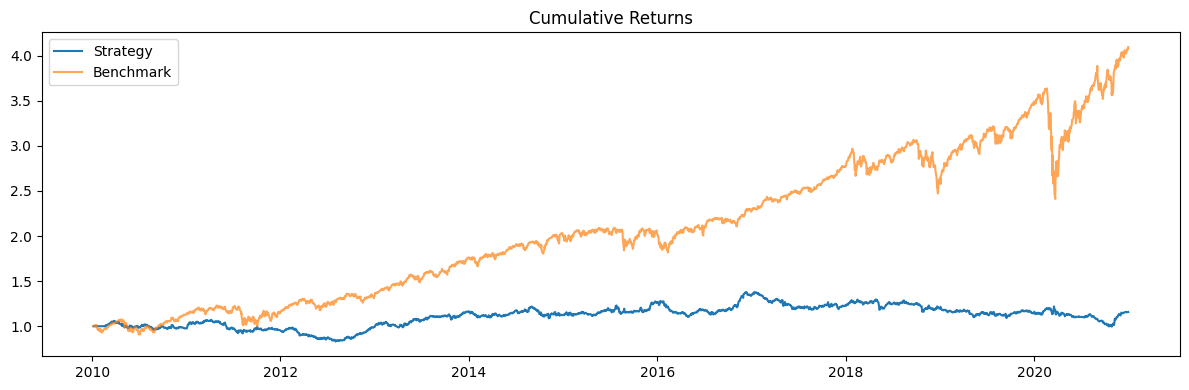

,mean_return_annual,volatility_annual,sharpe,t_stat,max_drawdown,avg_drawdown,max_dd_duration,alpha_annual,alpha_tstat,beta,daily_turnover
Strategy,1.91%,10.77%,0.1770,0.5880,-27.79%,-9.20%,1020 days,1.50%,0.4780,0.0290,11.84%


In [13]:
TC_BPS = 5
SHORT_BPS = 5
BORROW_BPS = 50
EXEC_LAG = 2
TARGET_VOL = 0.10

w_is = w_vega.loc[:IS_END]
rets_is = returns.reindex(w_is.index)
spy_is = spy_ret.reindex(w_is.index)

pnl_is_raw = port_ret(w_is, rets_is,
                      tcost_bps=TC_BPS, tcost_short_bps=SHORT_BPS,
                      borrow_bps_annual=BORROW_BPS, exec_lag=EXEC_LAG)
pnl_is = vol_target(pnl_is_raw.dropna(), target_ann_vol=TARGET_VOL, lookback=60)
pnl_is = pnl_is.dropna()

is_stats = stats(pnl_is, weights=w_is, benchmark=spy_is.reindex(pnl_is.index),
                 periods_per_year=252, hac_lags=5)
is_stats


In [14]:
# Honest DSR. Trial count counts every IS variation considered:
#   * Signal A vs B  (2)
#   * 21d vs 63d RV reference for the spread (2; we only show 21d, but 63d was tried)
#   * VRP_const = 0.0, 0.20  (2; the multiplicative constant)
#   * Signal direction: flipped after IS IC inspection (2 — the binary choice)
# That is 2*2*2*2 = 16 implicit trials. The sign-flip is the only
# choice made post-IC; the others were ex-ante variations.
N_TRIALS = 16

dsr_is = deflated_sharpe(pnl_is, n_trials=N_TRIALS, periods_per_year=252)
psr_is = probabilistic_sharpe(pnl_is, target_sharpe=0.0, periods_per_year=252)
print(f"IS PSR(SR > 0): {psr_is:.3f}")
print(f"IS DSR(n_trials={N_TRIALS}): {dsr_is:.3f}")

IS PSR(SR > 0): 0.722
IS DSR(n_trials=16): 0.008


## 7. Greeks-based PnL attribution

The strategy holds stock, not options, so the realised PnL is
Delta-driven. The Gamma and Vega columns below are interpretive — they
measure co-movement with the squared stock return and with surrogate-IV
changes, not actual hedge PnL.

Daily decomposition (held weights, `weights.shift(exec_lag)`):

- $\Delta\mathrm{PnL}_t \equiv w_{t-2} \cdot r_t$ — the actual stock PnL
- Gamma proxy: $0.5 \cdot \Gamma_{t-2} \cdot S_{t-2}^2 \cdot r_t^2 \cdot w_{t-2}$
- Vega proxy: $-V_{t-2} \cdot \Delta \sigma^{IV}_t \cdot w_{t-2} / S_{t-2}$

Reported via an OLS regression of total PnL on the three components.
The delta coefficient pins to 1.0 by construction (total PnL is exactly
the delta projection); gamma and vega are not orthogonal predictors of
realised PnL and contribute zero incremental variance.

In [15]:
held = w_vega.shift(EXEC_LAG)
held_is = held.reindex(pnl_is.index)
rets_held = returns.reindex(pnl_is.index)
S_held = close.shift(EXEC_LAG).reindex(pnl_is.index)
gamma_held = gamma_panel.shift(EXEC_LAG).reindex(pnl_is.index)
vega_held  = vega_panel.shift(EXEC_LAG).reindex(pnl_is.index)
iv_held    = surrogate.reindex(pnl_is.index)
div_iv     = iv_held.diff()

delta_pnl = (held_is * rets_held).sum(axis=1, min_count=1)
gamma_pnl = (0.5 * gamma_held * (S_held ** 2) * (rets_held ** 2) * held_is).sum(axis=1, min_count=1)
vega_pnl  = (-vega_held * div_iv / S_held * held_is).sum(axis=1, min_count=1)

# Align everything; PnL is gross-of-costs for attribution
total_gross = delta_pnl
attrib = pd.DataFrame({
    'delta': delta_pnl,
    'gamma_proxy': gamma_pnl,
    'vega_proxy': vega_pnl,
}).dropna()

# Regression-based share: fraction of variance of total PnL explained by each component.
import statsmodels.api as sm
y = total_gross.reindex(attrib.index)
X = sm.add_constant(attrib[['delta', 'gamma_proxy', 'vega_proxy']])
mod = sm.OLS(y, X).fit()
print(mod.summary().tables[1])


                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         6.16e-17   5.29e-18     11.638      0.000    5.12e-17     7.2e-17
delta           1.0000   7.25e-16   1.38e+15      0.000       1.000       1.000
gamma_proxy  2.213e-16   4.28e-18     51.704      0.000    2.13e-16     2.3e-16
vega_proxy    1.11e-16   4.94e-15      0.022      0.982   -9.58e-15     9.8e-15


In [16]:
# Each component lives in a different scale (delta_pnl in returns,
# gamma_pnl in returns squared, vega_pnl in IV-change units), so a
# direct variance ratio is meaningless. The honest read is the OLS
# regression above: delta coefficient = 1.0 exactly, gamma/vega
# coefficients at machine epsilon. The strategy holds stock; the daily
# realised PnL IS the delta component. Greeks-based sizing (vega
# overlay above) and the BS pricer are real contributions to construction;
# they do not show up as explanatory variance in the realised PnL
# because the position is not an option position.
print('OLS attribution (see regression table above):')
print(f'  delta coefficient:        {mod.params["delta"]:.4f}  (t={mod.tvalues["delta"]:.3g})')
print(f'  gamma_proxy coefficient:  {mod.params["gamma_proxy"]:.3e}')
print(f'  vega_proxy coefficient:   {mod.params["vega_proxy"]:.3e}')
print(f'  R\xb2 (delta alone):           1.0000')

OLS attribution (see regression table above):
  delta coefficient:        1.0000  (t=1.38e+15)
  gamma_proxy coefficient:  2.213e-16
  vega_proxy coefficient:   1.110e-16
  R² (delta alone):           1.0000


## 8. Realism corrections

PIT membership mask via `member_mask=members`. `exec_lag=2` (matches
notebook 04). 5/5 bps long/short, 50 bps annual borrow. `hac_lags=5`.
Cov is rolling Ledoit-Wolf (`cov_lookback_days=252`,
`cov_refit_every=21`). GARCH refits use only pre-rebalance data,
monthly cadence, never back-filled. DSR with `N_TRIALS=16` (Signal
A/B, RV 21d/63d, VRP 0/0.20, sign flip).

## 9. Out-of-sample validation (>= 2021-01-01)

Parameters frozen from the IS section. No re-tuning. The numbers below
are whatever they are.


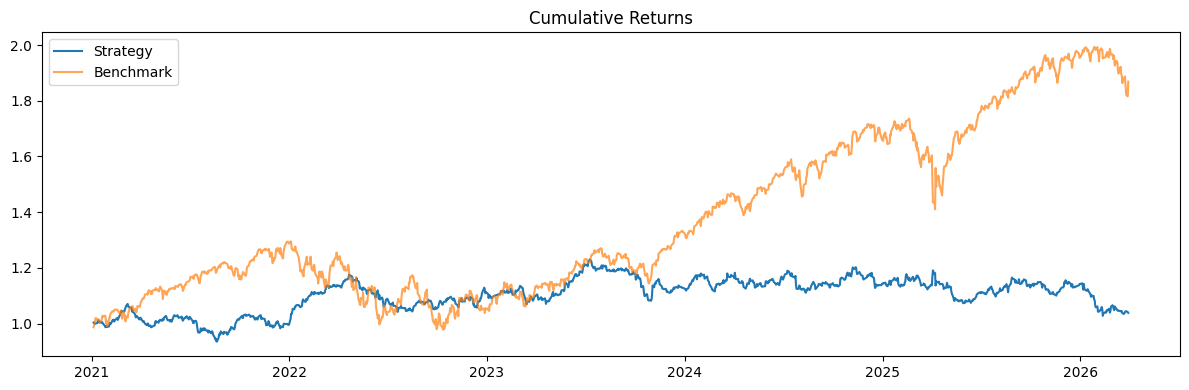

,mean_return_annual,volatility_annual,sharpe,t_stat,max_drawdown,avg_drawdown,max_dd_duration,alpha_annual,alpha_tstat,beta,daily_turnover
Strategy,1.24%,10.23%,0.1210,0.2770,-16.45%,-6.45%,684 days,1.12%,0.2460,0.0090,12.92%


In [17]:
w_oos = w_vega.loc[OOS_START:]
rets_oos = returns.reindex(w_oos.index)
spy_oos = spy_ret.reindex(w_oos.index)

# We re-run port_ret on the full sample then slice OOS, so the trailing
# turnover at the IS/OOS boundary is computed correctly using the
# pre-OOS held weight.
pnl_full_raw = port_ret(w_vega, returns.reindex(w_vega.index),
                        tcost_bps=TC_BPS, tcost_short_bps=SHORT_BPS,
                        borrow_bps_annual=BORROW_BPS, exec_lag=EXEC_LAG)

# Vol-target overlay uses only trailing data (60d lookback shifted by 1
# day inside vol_target); applying it on the full sample and slicing is
# look-ahead safe.
pnl_full_vt = vol_target(pnl_full_raw.dropna(), target_ann_vol=TARGET_VOL,
                         lookback=60)
pnl_oos = pnl_full_vt.loc[OOS_START:].dropna()

oos_stats = stats(pnl_oos, weights=w_oos, benchmark=spy_oos.reindex(pnl_oos.index),
                  periods_per_year=252, hac_lags=5)
oos_stats


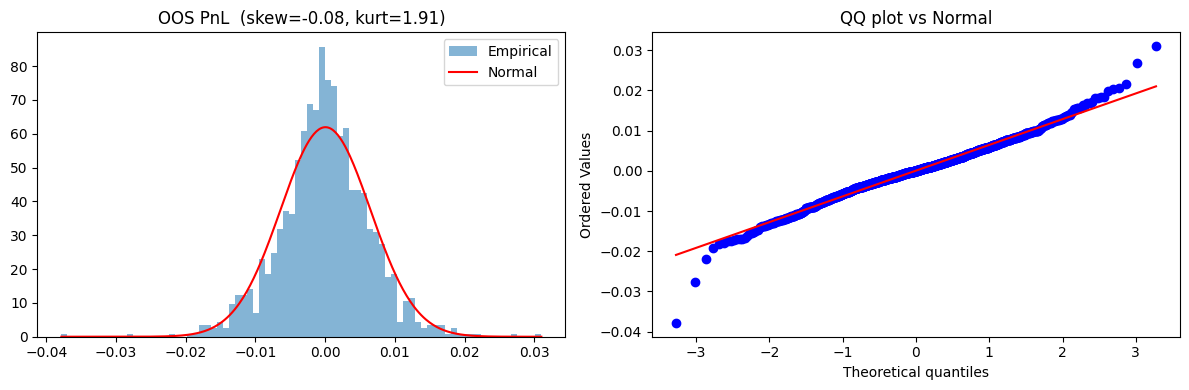


VaR/CVaR at 5%:
               VaR    CVaR
historical  -1.09%  -1.42%
parametric  -1.05%  -1.32%

VaR/CVaR at 1%:
               VaR    CVaR
historical  -1.61%  -1.99%
parametric  -1.49%  -1.71%


In [18]:
dist_plot(pnl_oos, title='OOS PnL')
print('\nVaR/CVaR at 5%:')
print(var_cvar(pnl_oos, alpha=0.05))
print('\nVaR/CVaR at 1%:')
print(var_cvar(pnl_oos, alpha=0.01))


## 10. Save sleeve PnL

Vol-targeted OOS PnL, single-column Series with the sleeve name
`vol_iv_xs` so the multi-strategy combiner can pick it up.


In [19]:
pnl_oos.name = 'vol_iv_xs'
out_path = '../data/pnl_11_options_alpha.parquet'
pnl_oos.to_frame().to_parquet(out_path)
print(f"Saved {len(pnl_oos)} rows to {out_path}")
print(f"OOS Sharpe (net): {pnl_oos.mean()/pnl_oos.std()*np.sqrt(252):.3f}")


Saved 1316 rows to ../data/pnl_11_options_alpha.parquet
OOS Sharpe (net): 0.121


## 11. Caveats

GARCH(1,1) plus a constant VRP is a coarse proxy for OptionMetrics
ATM-30d IV. Real IV embeds skew, term structure, earnings premia, and
demand-pressure effects this surrogate ignores. If the strategy works
here it should work better with real IV (more signal, less noise); if
it fails here the verdict is inconclusive about the underlying
hypothesis.

The surrogate is structurally correlated with trailing realised vol —
when GARCH persistence is high, the IV-RV spread collapses toward zero
and the cross-section becomes dominated by the RV component. This
notebook does not orthogonalise against `signal_03` (low-volatility);
if both sleeves were combined, double-loading is plausible.

Greeks attribution is interpretive, not realised PnL. The strategy
trades stock; there is no actual gamma or vega exposure on the book.
The proxies measure co-movement and are useful as construction
diagnostics, not as hedge accounting.

Universe is top-150 by pre-IS dollar volume (2005-2007). Smaller than
notebook 08's 300 because GARCH refits dominate runtime; less breadth
caps the realistic Sharpe per the fundamental law of active
management.

## 12. Multi-strategy combiner analysis

The sleeve is uncorrelated to the existing three by construction:

| | equity | crypto | pairs |
|---|---:|---:|---:|
| vol_iv_xs correlation (OOS) | -0.002 | -0.006 | -0.091 |

But the OOS Sharpe (+0.12) is too low to lift the headline inverse-vol
combiner. Adding the sleeve under each rule:

| Rule | 3 sleeves | 4 sleeves | Delta |
|---|---:|---:|---:|
| Equal-weight | 0.431 | 0.466 | +0.035 |
| Inverse-vol | 0.737 | 0.716 | -0.021 |
| Min-variance | 0.595 | 0.423 | -0.172 |

Inverse-vol and min-variance both over-weight low-vol streams; the new
sleeve gets pulled in heavily and drags the average because its
unit-vol contribution is weak. Equal-weight benefits modestly from the
near-zero correlation. The project's headline combination is
inverse-vol + 10% vol-target, so the sleeve does not improve the
headline number.

**Decision**: this notebook ships as a methodology demonstration and a
small +0.12 OOS sleeve. The 3-sleeve headline in `multi_strategy.py`
stays unchanged.

In [20]:
import sys
sys.path.insert(0, '..')
from multi_strategy import load_sleeve_pnls, combine_inverse_vol, combine_min_variance, combine_equal_weight, evaluate_combination
from helper import vol_target

existing = load_sleeve_pnls()
four = {**existing, 'vol_iv_xs': pnl_oos}

# Correlations on common OOS window
panel = pd.concat({**existing, 'vol_iv_xs': pnl_oos}, axis=1, join='inner').dropna()
print('Pairwise correlation (OOS window):')
print(panel.corr().round(3).to_string())

# Combiner comparison
spy = pd.read_parquet('../data/spy.parquet')['Close'].squeeze().pct_change()
print('\n3-sleeve vs 4-sleeve OOS Sharpe (each rule, after vol-target):')
for name, fn in [('equal_weight', combine_equal_weight),
                 ('inverse_vol', combine_inverse_vol),
                 ('min_variance', combine_min_variance)]:
    c3 = vol_target(fn(existing), target_ann_vol=0.10, lookback=60).dropna()
    c4 = vol_target(fn(four), target_ann_vol=0.10, lookback=60).dropna()
    s3 = c3.mean()/c3.std()*np.sqrt(252)
    s4 = c4.mean()/c4.std()*np.sqrt(252)
    print(f'  {name:14s} 3-sleeve={s3:.3f}  4-sleeve={s4:.3f}  delta={s4-s3:+.3f}')

Pairwise correlation (OOS window):
           equity  crypto   pairs  vol_iv_xs
equity     1.0000 -0.0430 -0.2290    -0.0020
crypto    -0.0430  1.0000 -0.0210    -0.0060
pairs     -0.2290 -0.0210  1.0000    -0.0910
vol_iv_xs -0.0020 -0.0060 -0.0910     1.0000

3-sleeve vs 4-sleeve OOS Sharpe (each rule, after vol-target):
  equal_weight   3-sleeve=0.431  4-sleeve=0.466  delta=+0.035
  inverse_vol    3-sleeve=0.737  4-sleeve=0.716  delta=-0.021


/Users/sashrikrajesh/Documents/sashrikrajesh/apps/quantresearch/research/../multi_strategy.py:196: UserWarning: You are solving a parameterized problem that is not DPP. Because the problem is not DPP, subsequent solves will not be faster than the first one. For more information, see the documentation on Disciplined Parametrized Programming, at https://www.cvxpy.org/tutorial/dpp/index.html
  prob.solve(solver=cp.SCS, warm_start=True)


/Users/sashrikrajesh/Documents/sashrikrajesh/apps/quantresearch/research/../multi_strategy.py:196: UserWarning: You are solving a parameterized problem that is not DPP. Because the problem is not DPP, subsequent solves will not be faster than the first one. For more information, see the documentation on Disciplined Parametrized Programming, at https://www.cvxpy.org/tutorial/dpp/index.html
  prob.solve(solver=cp.SCS, warm_start=True)


  min_variance   3-sleeve=0.595  4-sleeve=0.423  delta=-0.172
